# Imports

In [476]:
%load_ext autoreload
%autoreload 2

from llmperf.config.workloads import get_workload_by_alias
from typing import Dict, List
from llmperf.postprocessing.output import ExperimentOutput
from collections import defaultdict
import os
import json
from eval_plots import plot_grouped_video_bars, plot_latency_breakdown_videos,\
    parse_logs_videos, get_metric_fn, filter_nested_data, analyze_nested_data_change,\
    normalize_nested_data_to_base_frame, calculate_average_change_from_base, calculate_average_relative_score,\
    save_figure_as_pdf, plot_grouped_video_bars_multi_data, plot_grouped_bar_chart
# from llmperf.constants import EXPERIMENTS_LOG
EXPERIMENTS_LOG = "/home/ioannis.dalianis/code/las_konpap/mllm-inference-workload-eval/artifacts/outputs/benchmark-log-videos.jsonl"
MODAL_OUTPUTS = "/home/ioannis.dalianis/code/las_konpap/mllm-inference-workload-eval/artifacts/outputs/outputs-videos"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Evaluator Class

In [477]:
class Evaluator:
    def __init__(self, workload_alias: str, eo_id: str):
        self.workload = get_workload_by_alias(workload_alias)

        if len(self.workload.requests) == 0:
            self.workload.load()

        # self.eo = ExperimentOutput(id=eo_id)
        self.eo = ExperimentOutput(id=eo_id, output_path=MODAL_OUTPUTS)
        self.eo.load()

        assert len(self.workload.requests) == len(self.eo.request_outputs)

    def evaluate(self, metrics: List[str]) -> Dict[str, float]:
        scores = {}
        for metric in metrics:
            metric_fn = get_metric_fn(metric, self.workload.alias)
            score = metric_fn(
                self.workload.requests,
                self.eo.request_outputs
            )
            scores[metric] = score

        return scores

# Main

## Check accuracy - Works fine

In [478]:
# read_jsonl = "/home/ioannis.dalianis/code/las_konpap/mllm-inference-workload-eval/artifacts/outputs/outputs-videos/videomme-mc__llava-ov__iso__v0.0.1.baseline__20251024-151137__maxlendef__batchdef__blocksdef__gpu0.95__swap0__stratuniform__frame4.jsonl"
read_jsonl = "/home/ioannis.dalianis/code/las_konpap/mllm-inference-workload-eval/artifacts/outputs/outputs-videos/videomme-mc__llava-ov__iso__v0.0.1.baseline__20251024-160924__maxlendef__batchdef__blocksdef__gpu0.95__swap0__stratuniform__frame64.jsonl"
read_ground_truth = "/home/ioannis.dalianis/code/las_konpap/mllm-inference-workload-eval/artifacts/outputs/videomme-mc.jsonl"

def acc_count(ground_truth, output):
    if ground_truth == output:
        return 1
    return 0

total = 0
correct = 0
with open(read_jsonl) as f:
    with open(read_ground_truth) as f_ground_truth:
        lines = f.readlines()
        lines_ground_truth = f_ground_truth.readlines()

        for line, line_ground_truth in zip(lines, lines_ground_truth):
            
            data = json.loads(line)
            data_ground_truth = json.loads(line_ground_truth)["request"]

            # print(data["id"], data["outputs"], "|", data_ground_truth["id"], data_ground_truth["output"])
            total += 1
            correct += acc_count(data_ground_truth["output"], data["outputs"][0])

print("Accuracy:", correct / total)

Accuracy: 0.6457142857142857


## Prepare Experiments

In [479]:
# Load experiment outputs from benchmark logs
experiment_ids = parse_logs_videos(EXPERIMENTS_LOG)
print(experiment_ids.keys())
# for i in experiment_ids:
#     for j in experiment_ids[i]:
#         print(i, j, experiment_ids[i][j])

dict_keys(['videomme-mc', 'mmbench-video-qna', 'tempcompass-captioning'])


In [480]:
try:
    scores # check if scores already exists
except NameError:
    scores = defaultdict(lambda: defaultdict(dict))
    ttfts = defaultdict(lambda: defaultdict(dict))
    avg_modality_tokens = defaultdict(lambda: defaultdict(dict))
    preprocess_times = defaultdict(lambda: defaultdict(dict))
    encoder_times = defaultdict(lambda: defaultdict(dict))

    for wl_alias in experiment_ids.keys():
        print(f"Calculating for dataset {wl_alias}")
        if wl_alias in ["mmbench-mc", "videomme-mc"]:
            metric = "accuracy"
        else:
            metric = "rouge-l"

        for model in experiment_ids[wl_alias].keys():
            print(f"\tCalculating for model {model}")
            for cr in experiment_ids[wl_alias][model].keys():
                print(f"\t\tCalculating for cr {cr}")
                for frame_num in experiment_ids[wl_alias][model][cr].keys():
                    # print(f"\t\t\tCalculating for frame {frame_num}")
                    
                    eo_id = experiment_ids[wl_alias][model][cr][frame_num]
                    try:
                        # 1. Attempt to access the deeply nested value directly.
                        # If any key is missing (wl_alias, model, or cr), a KeyError will be raised.
                        score_exists = scores[wl_alias][model][cr][frame_num]
                    except KeyError:
                        evaluator = Evaluator(wl_alias, eo_id)
                        score = evaluator.evaluate([metric])
                        if cr in scores[wl_alias][model]:
                            scores[wl_alias][model][cr][frame_num] = score[metric]
                        else:
                            scores[wl_alias][model][cr] = {frame_num: score[metric]}

                        eo = ExperimentOutput(id=eo_id, output_path=MODAL_OUTPUTS)
                        eo.load()
                        ttft = eo.ttft_latency("mean")
                        if cr in ttfts[wl_alias][model]:
                            ttfts[wl_alias][model][cr][frame_num] = ttft
                        else:
                            ttfts[wl_alias][model][cr] = {frame_num: ttft}
                    
                        preprocess_time = eo.preprocess_times("mean")
                        if cr in preprocess_times[wl_alias][model]:
                            preprocess_times[wl_alias][model][cr][frame_num] = preprocess_time
                        else:
                            preprocess_times[wl_alias][model][cr] = {frame_num: preprocess_time}

                        encoder_time = eo.encoder_times("mean")
                        if cr in encoder_times[wl_alias][model]:
                            encoder_times[wl_alias][model][cr][frame_num] = encoder_time
                        else:
                            encoder_times[wl_alias][model][cr] = {frame_num: encoder_time}

                        avg_modality_token = eo.avg_modality_tokens("mean")
                        if cr in avg_modality_tokens[wl_alias][model]:
                            avg_modality_tokens[wl_alias][model][cr][frame_num] = avg_modality_token
                        else:
                            avg_modality_tokens[wl_alias][model][cr] = {frame_num: avg_modality_token}

In [481]:
print(scores.keys())
# scores
# preprocess_times
# encoder_times
# ttfts

dict_keys(['videomme-mc', 'mmbench-video-qna', 'tempcompass-captioning'])


### Compute Prompt Preparation Time (Clever Sampling Time)

In [482]:
task_jsonls = [ # files with ground truth
    "/home/ioannis.dalianis/code/las_konpap/mllm-inference-workload-eval/artifacts/outputs/mmbench-video-qna.jsonl",
    "/home/ioannis.dalianis/code/las_konpap/mllm-inference-workload-eval/artifacts/outputs/videomme-mc.jsonl",
    "/home/ioannis.dalianis/code/las_konpap/mllm-inference-workload-eval/artifacts/outputs/tempcompass-captioning.jsonl"
    ]
starts_withs = [ # prefixes of result files
    "mmbench-video-qna__llava-ov-small__iso__v0.0.1.baseline",
    "videomme-mc__llava-ov-small__iso__v0.0.1.baseline",
    "tempcompass-captioning__llava-ov-small__iso__v0.0.1.baseline"
]

outputs_videos_path = "/home/ioannis.dalianis/code/las_konpap/mllm-inference-workload-eval/artifacts/outputs/outputs-videos/"

try:
    prompt_prep_times_all_ids # check if prompt_prep_times_all_ids already exists
except NameError:
    # Dictionary to hold prompt preparation times for all IDs - it doesn't yet keep have only the max (the first preparation time that got cached later)
    prompt_prep_times_all_ids = defaultdict(lambda: defaultdict(dict))

    for idx_big, task_jsonl in enumerate(task_jsonls):
        with open(task_jsonl) as f:
            lines = f.readlines()

            all_unique_paths = set() # get unique modality paths
            for idx, line in enumerate(lines):
                data = json.loads(line)
                all_unique_paths.add(data["request"]["modality_path"])

            print("All unique modality paths:", len(all_unique_paths))

            all_asociated_ids = dict()  # show associated ids and keep unique
            for unique_path in all_unique_paths:
                for idx, line in enumerate(lines):
                    data = json.loads(line)
                    if data["request"]["modality_path"] == unique_path:
                        
                        if data["request"]["modality_path"] not in all_asociated_ids:
                            all_asociated_ids[data["request"]["modality_path"]] = {data["request"]["id"]}
                        else:
                            all_asociated_ids[data["request"]["modality_path"]].add(data["request"]["id"])

            total_ids = 0
            for path in all_asociated_ids:
                # print("Modality path:", path, "-> Associated IDs:", all_asociated_ids[path])
                total_ids += len(all_asociated_ids[path])
            print("Total IDs:", total_ids)

        # for all video files keep prompt preparation times for every asociated id and modality path
        for video_file in sorted(os.listdir(outputs_videos_path)):
            if video_file.startswith(starts_withs[idx_big]):
                prompt_prep_times_all_ids[video_file] = {}
                
                with open(outputs_videos_path + video_file) as fresult_video_file:
                    lines_result_video_file = fresult_video_file.readlines()
                    for modality_path in all_asociated_ids:
                        for asociated_id in all_asociated_ids[modality_path]:
                            for result_line in lines_result_video_file:
                                data_result = json.loads(result_line)
                                if data_result["id"] == asociated_id:
                                    # print("\t\t\tprompt_preparation_time:", data_result["prompt_preparation_time"])
                                    prompt_prep_times_all_ids[video_file][modality_path] = prompt_prep_times_all_ids[video_file].get(modality_path, {})
                                    prompt_prep_times_all_ids[video_file][modality_path][asociated_id] = data_result["prompt_preparation_time"]
for video_file in prompt_prep_times_all_ids:
    print(video_file)
    for modality_path in prompt_prep_times_all_ids[video_file]:
        print("\tModality path:", modality_path)
        for asociated_id in prompt_prep_times_all_ids[video_file][modality_path]:
            ppt = prompt_prep_times_all_ids[video_file][modality_path][asociated_id]
            print("\t\tAssociated ID:", asociated_id, "-> Prompt Preparation Time (s):", ppt)
        break
    break

mmbench-video-qna__llava-ov-small__iso__v0.0.1.baseline__20251025-105920__maxlendef__batchdef__blocksdef__gpu0.95__swap0__stratuniform__frame4.jsonl
	Modality path: /srv/muse-lab/datasets/MMBench-Video/videos/qsqGAaEV3lw.mp4
		Associated ID: e8787d48 -> Prompt Preparation Time (s): 2.2444730300921947
		Associated ID: ad842707 -> Prompt Preparation Time (s): 2.138079899828881
		Associated ID: ed2c5b4b -> Prompt Preparation Time (s): 2.644761480856687
		Associated ID: 7a84bb5d -> Prompt Preparation Time (s): 2.200138720916584


### Keep only the max preparation time which is the first time sampling happended and the result was cached

In [483]:
prompt_preparation_times = defaultdict(lambda: defaultdict(dict))

for video_file in prompt_prep_times_all_ids:
    task_current = video_file.split("__")[0]
    model_current = video_file.split("__")[1]
    technique_current = video_file.split("__")[-2].replace("strat", "")
    frames_current = video_file.split("__")[-1].replace(".jsonl", "")
    # print("\tFrames:", frames_current)

    total_avg = 0
    total_count = 0
    # iterate over all video paths 
    for modality_path in prompt_prep_times_all_ids[video_file]:
        total_ppt = 0.0
        count = 0
        # for every path add the max or avg time of asociated ids
        for asociated_id in prompt_prep_times_all_ids[video_file][modality_path]:
            
            # if preparation_time_technique == "Average Max":
            ppt = prompt_prep_times_all_ids[video_file][modality_path][asociated_id]
            if ppt > total_ppt:
                total_ppt = ppt
        
        # if preparation_time_technique == "Average Add":
        #     avg_ppt = total_ppt / count if count > 0 else 0.0
        avg_ppt = total_ppt
        total_count += 1
        total_avg += avg_ppt
    
    total_avg = total_avg / total_count
    
    if technique_current in prompt_preparation_times[task_current][model_current]:
        prompt_preparation_times[task_current][model_current][technique_current][frames_current] = total_avg
    else:
        prompt_preparation_times[task_current][model_current][technique_current] = {frames_current: total_avg}

### This way I can remove keys from the dictionaries

In [484]:
remove_tasks={"llavabench-qna", "cocoval-captioning"}
# remove_techniques={"motion_based", "uniform", "sharpness_based"}
remove_techniques={"motion_based", "uniform", "sharpness_based"}

# remove_frames={'frame4', 'frame8', 'frame16', 'frame32'}
remove_frames={}

ttfts_with_prep_time = filter_nested_data(
    ttfts,
    remove_tasks={},
    remove_models={}, 
    remove_frames=remove_frames,
    remove_techniques={}
)

for task in ttfts_with_prep_time:
    for model in ttfts_with_prep_time[task]:
        for technique in ttfts_with_prep_time[task][model]:
            # print("\t\t", prompt_preparation_times[task][model][technique])
            for frame in ttfts_with_prep_time[task][model][technique]:
                prep_time = prompt_preparation_times[task]['llava-ov-small'][technique][frame] # always llava-ov-small
                ttfts_with_prep_time[task][model][technique][frame] += prep_time

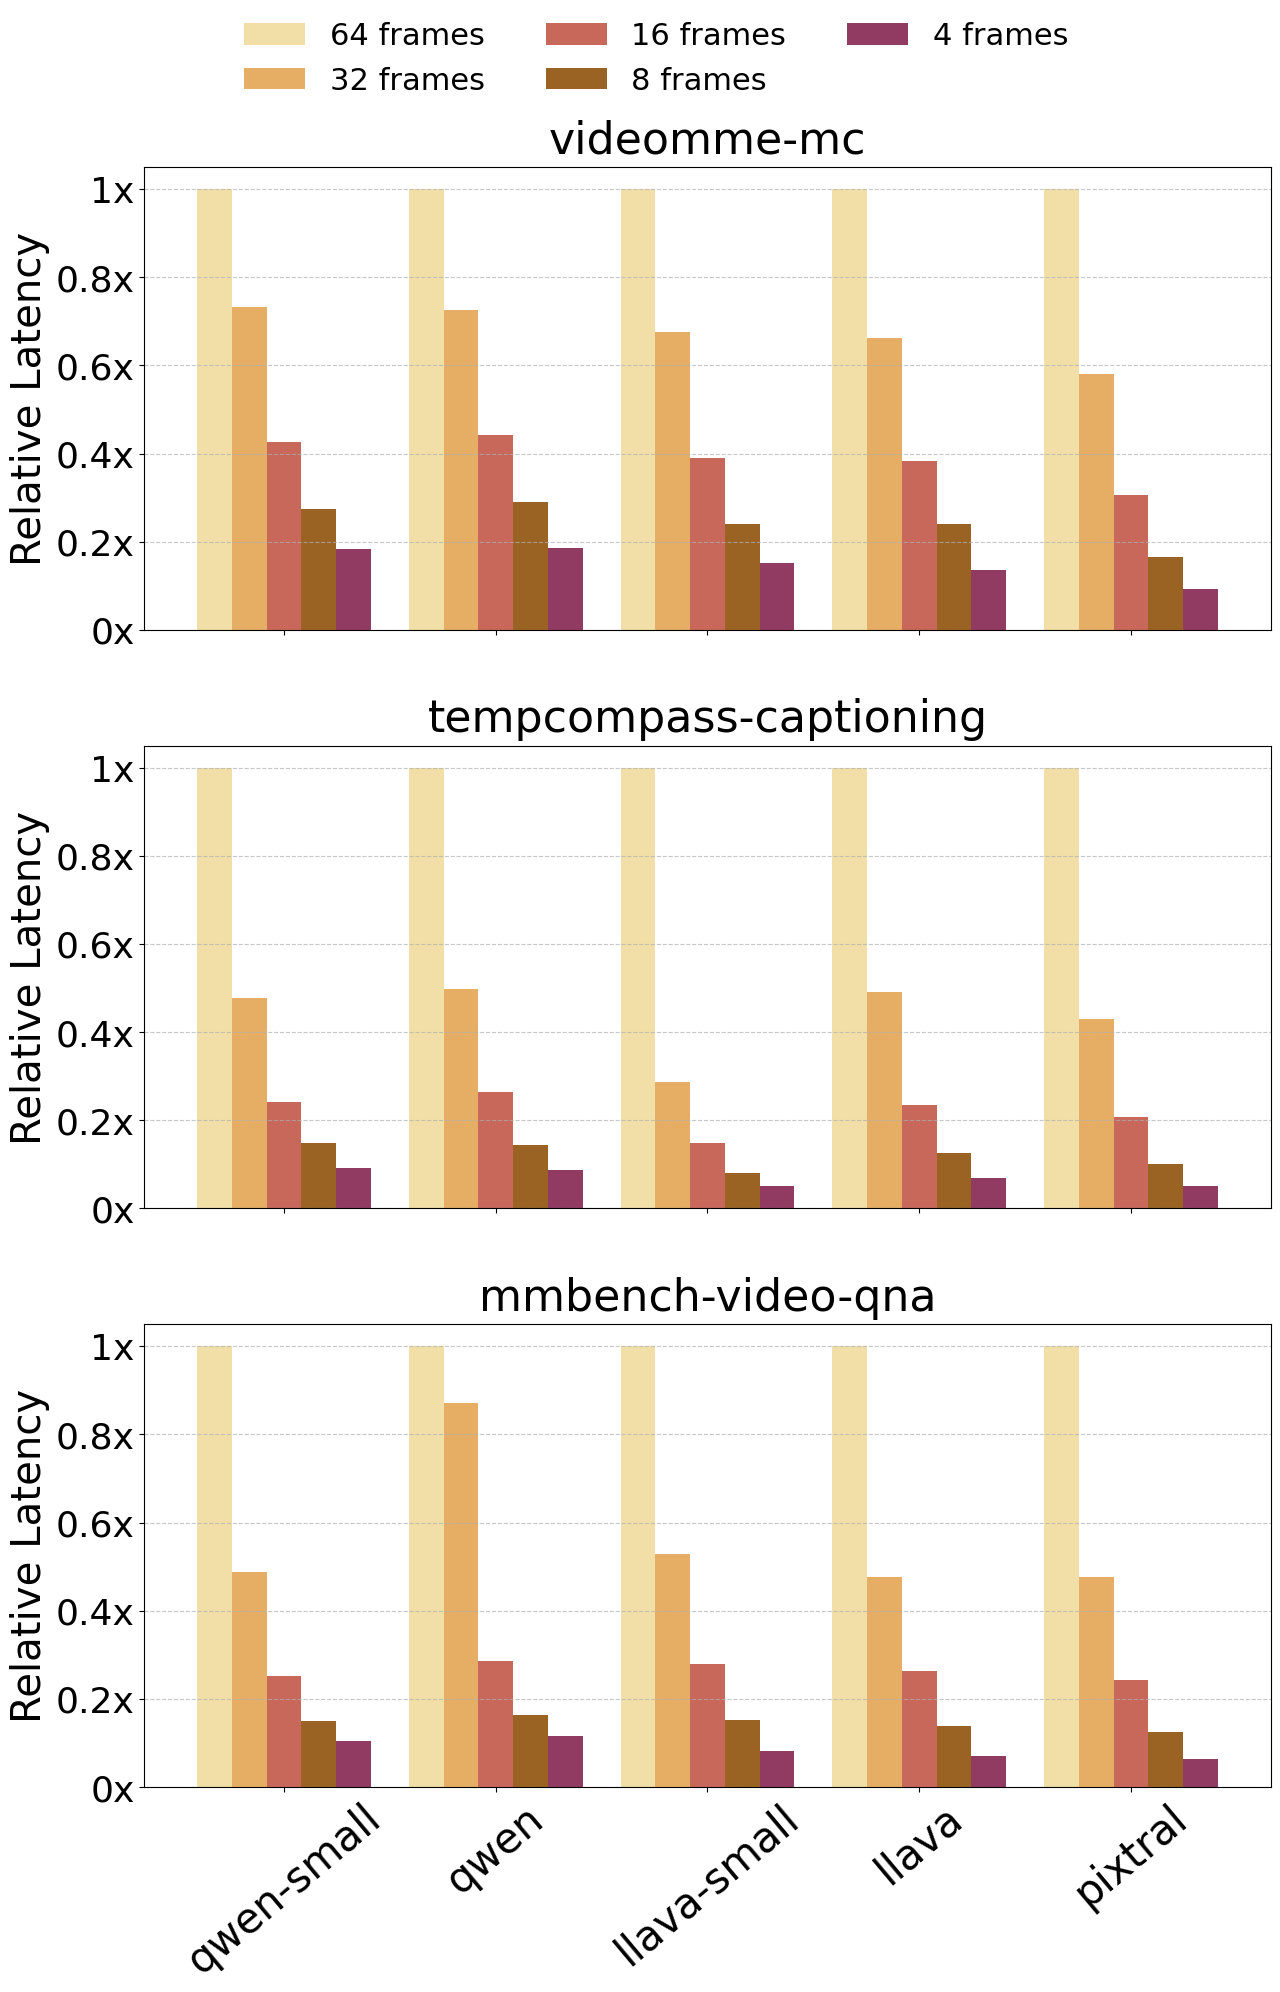

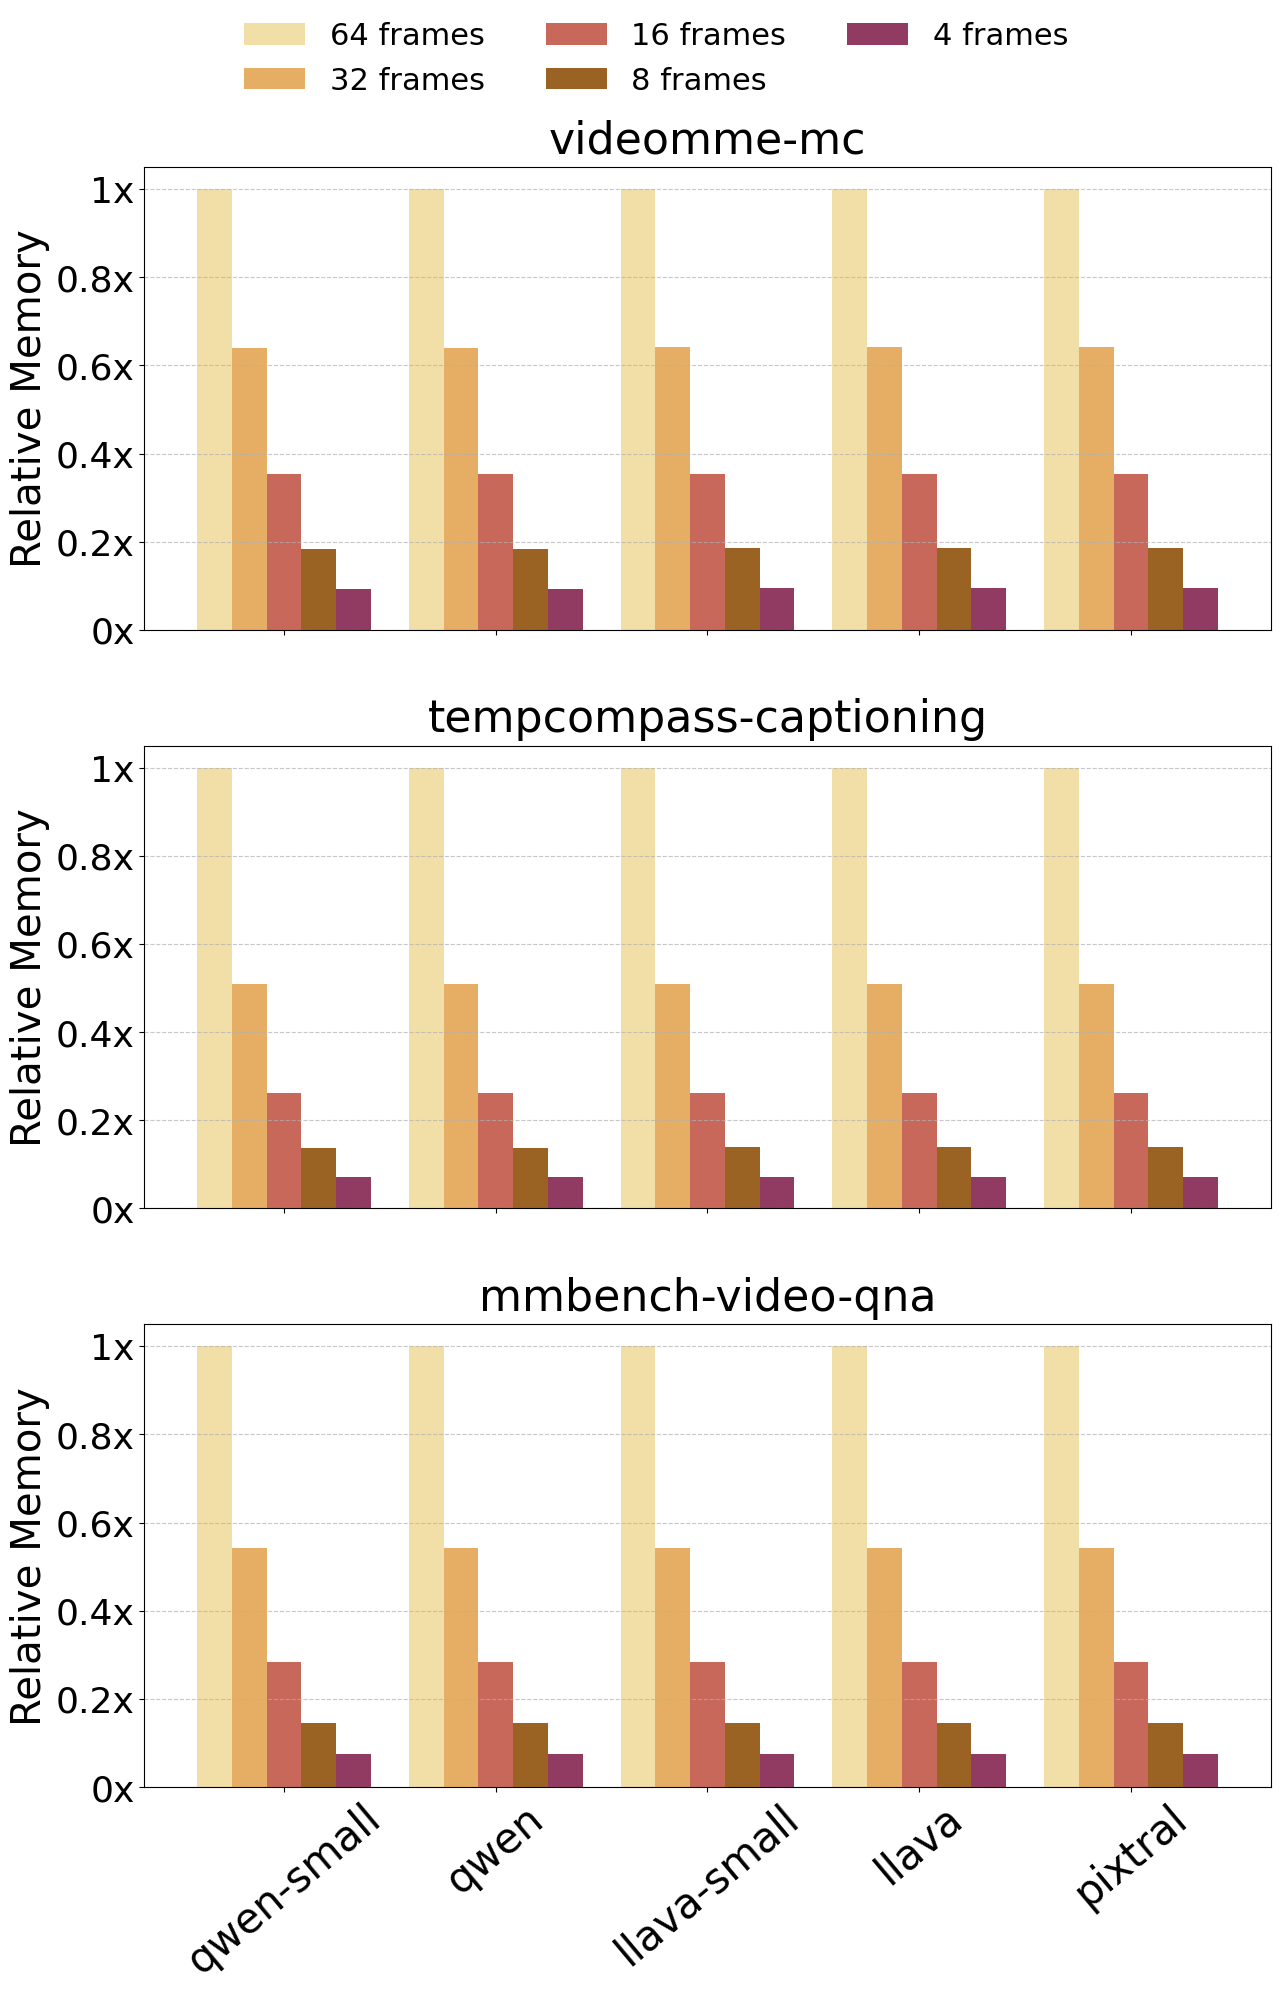

In [485]:
# fig = plot_grouped_video_bars_multi_data(scores, ["videomme-mc", "mmbench-video-qna", "tempcompass-captioning"], mode="model-technique|frame", show_legend=True, color_map="categorical", add_plot_title=True, title="Accuracy/Rouge-L")
# save_figure_as_pdf(fig, "video_datasets_compare_techniques_all_frames_accs")

# fig = plot_grouped_video_bars_multi_data(ttfts_with_prep_time, ["videomme-mc", "mmbench-video-qna", "tempcompass-captioning"],
#                                        mode="model-technique|frame", show_legend=True, title="Sampling +\nInference(s)",
#                                     log_threshold=10, color_map="categorical", add_plot_title=True)
# save_figure_as_pdf(fig, "video_datasets_compare_techniques_all_frames_times")

# fig = plot_grouped_video_bars_multi_data(avg_modality_tokens, ["videomme-mc", "mmbench-video-qna", "tempcompass-captioning"], mode="model-technique|frame",
#                                        title="Memory Footprint", show_legend=False,
#                                     color_map="categorical", add_plot_title=True)
# # save_figure_as_pdf(fig, "video_datasets_compare_techniques_all_frames_tokens")

# scores_removes_other_techniques = filter_nested_data(
#    scores,
#    remove_tasks={},
#    remove_models={}, 
#    remove_frames={},
#    remove_techniques={"uniform", "sharpness_based", "motion_based"}
# )
# # fig = plot_grouped_video_bars_multi_data(scores_removes_other_techniques,
# #                                          ["videomme-mc", "mmbench-video-qna", "tempcompass-captioning"],
# #                                          mode="model-frame|technique", show_legend=True, color_map="categorical", add_plot_title=True, title="Accuracy/Rouge-L")
# fig = plot_grouped_video_bars(scores_removes_other_techniques,
#                                   ['videomme-mc', 'tempcompass-captioning', 'mmbench-video-qna'],
#                                   mode="model-frame|technique",
#                                   show_legend=True, add_plot_title=False)
# # save_figure_as_pdf(fig, "video_experiments_scores")

ttfts_removes_other_techniques = filter_nested_data(
   ttfts,
   remove_tasks={},
   remove_models={}, 
   remove_frames={},
   remove_techniques={"uniform", "sharpness_based", "motion_based"}
)
ttft_reductions = normalize_nested_data_to_base_frame(ttfts_removes_other_techniques, direction='small_to_big')
fig = plot_grouped_video_bars(ttft_reductions,
                                  ['videomme-mc', 'tempcompass-captioning', 'mmbench-video-qna'],
                                  mode="model-frame|technique", title="Relative Latency",
                                  show_legend=True, add_plot_title=False, add_suffix=True)
# # save_figure_as_pdf(fig, "video_experiments_latency")

mod_tokens_removes_other_techniques = filter_nested_data(
   avg_modality_tokens,
   remove_tasks={},
   remove_models={}, 
   remove_frames={},
   remove_techniques={"uniform", "sharpness_based", "motion_based"}
)
token_reductions = normalize_nested_data_to_base_frame(mod_tokens_removes_other_techniques, direction='small_to_big')
fig = plot_grouped_video_bars(token_reductions,
                                  ['videomme-mc', 'tempcompass-captioning', 'mmbench-video-qna'],
                                  mode="model-frame|technique", title="Relative Memory",
                                  show_legend=True, add_plot_title=False, add_suffix=True)
# save_figure_as_pdf(fig, "video_experiments_memory")

## Justify scene_change

Plotting for task videomme-mc in mode model-technique|frame


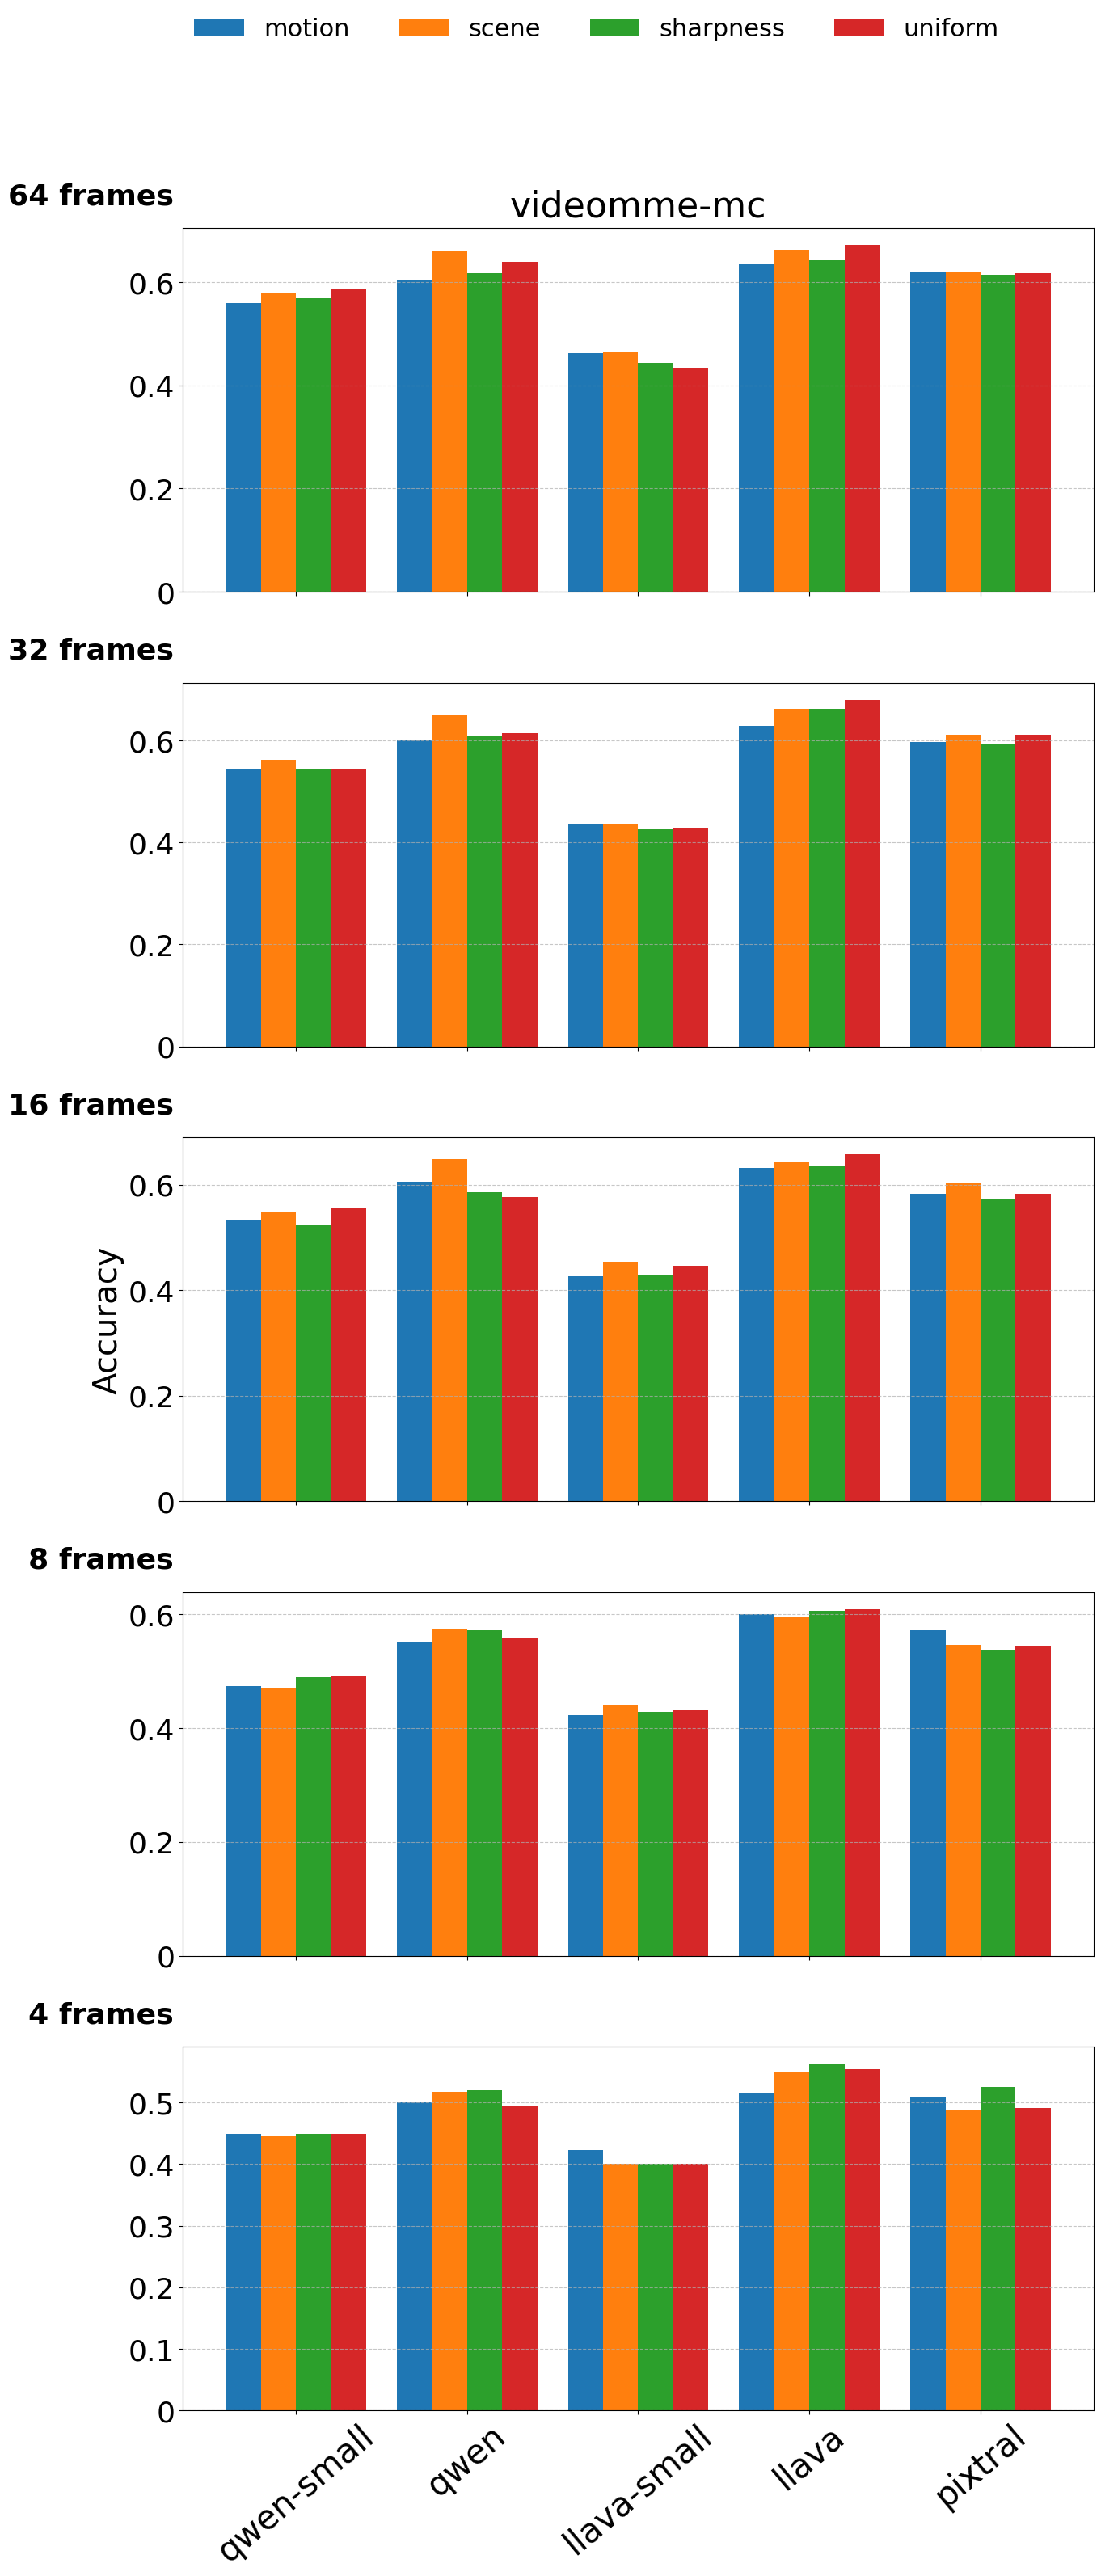

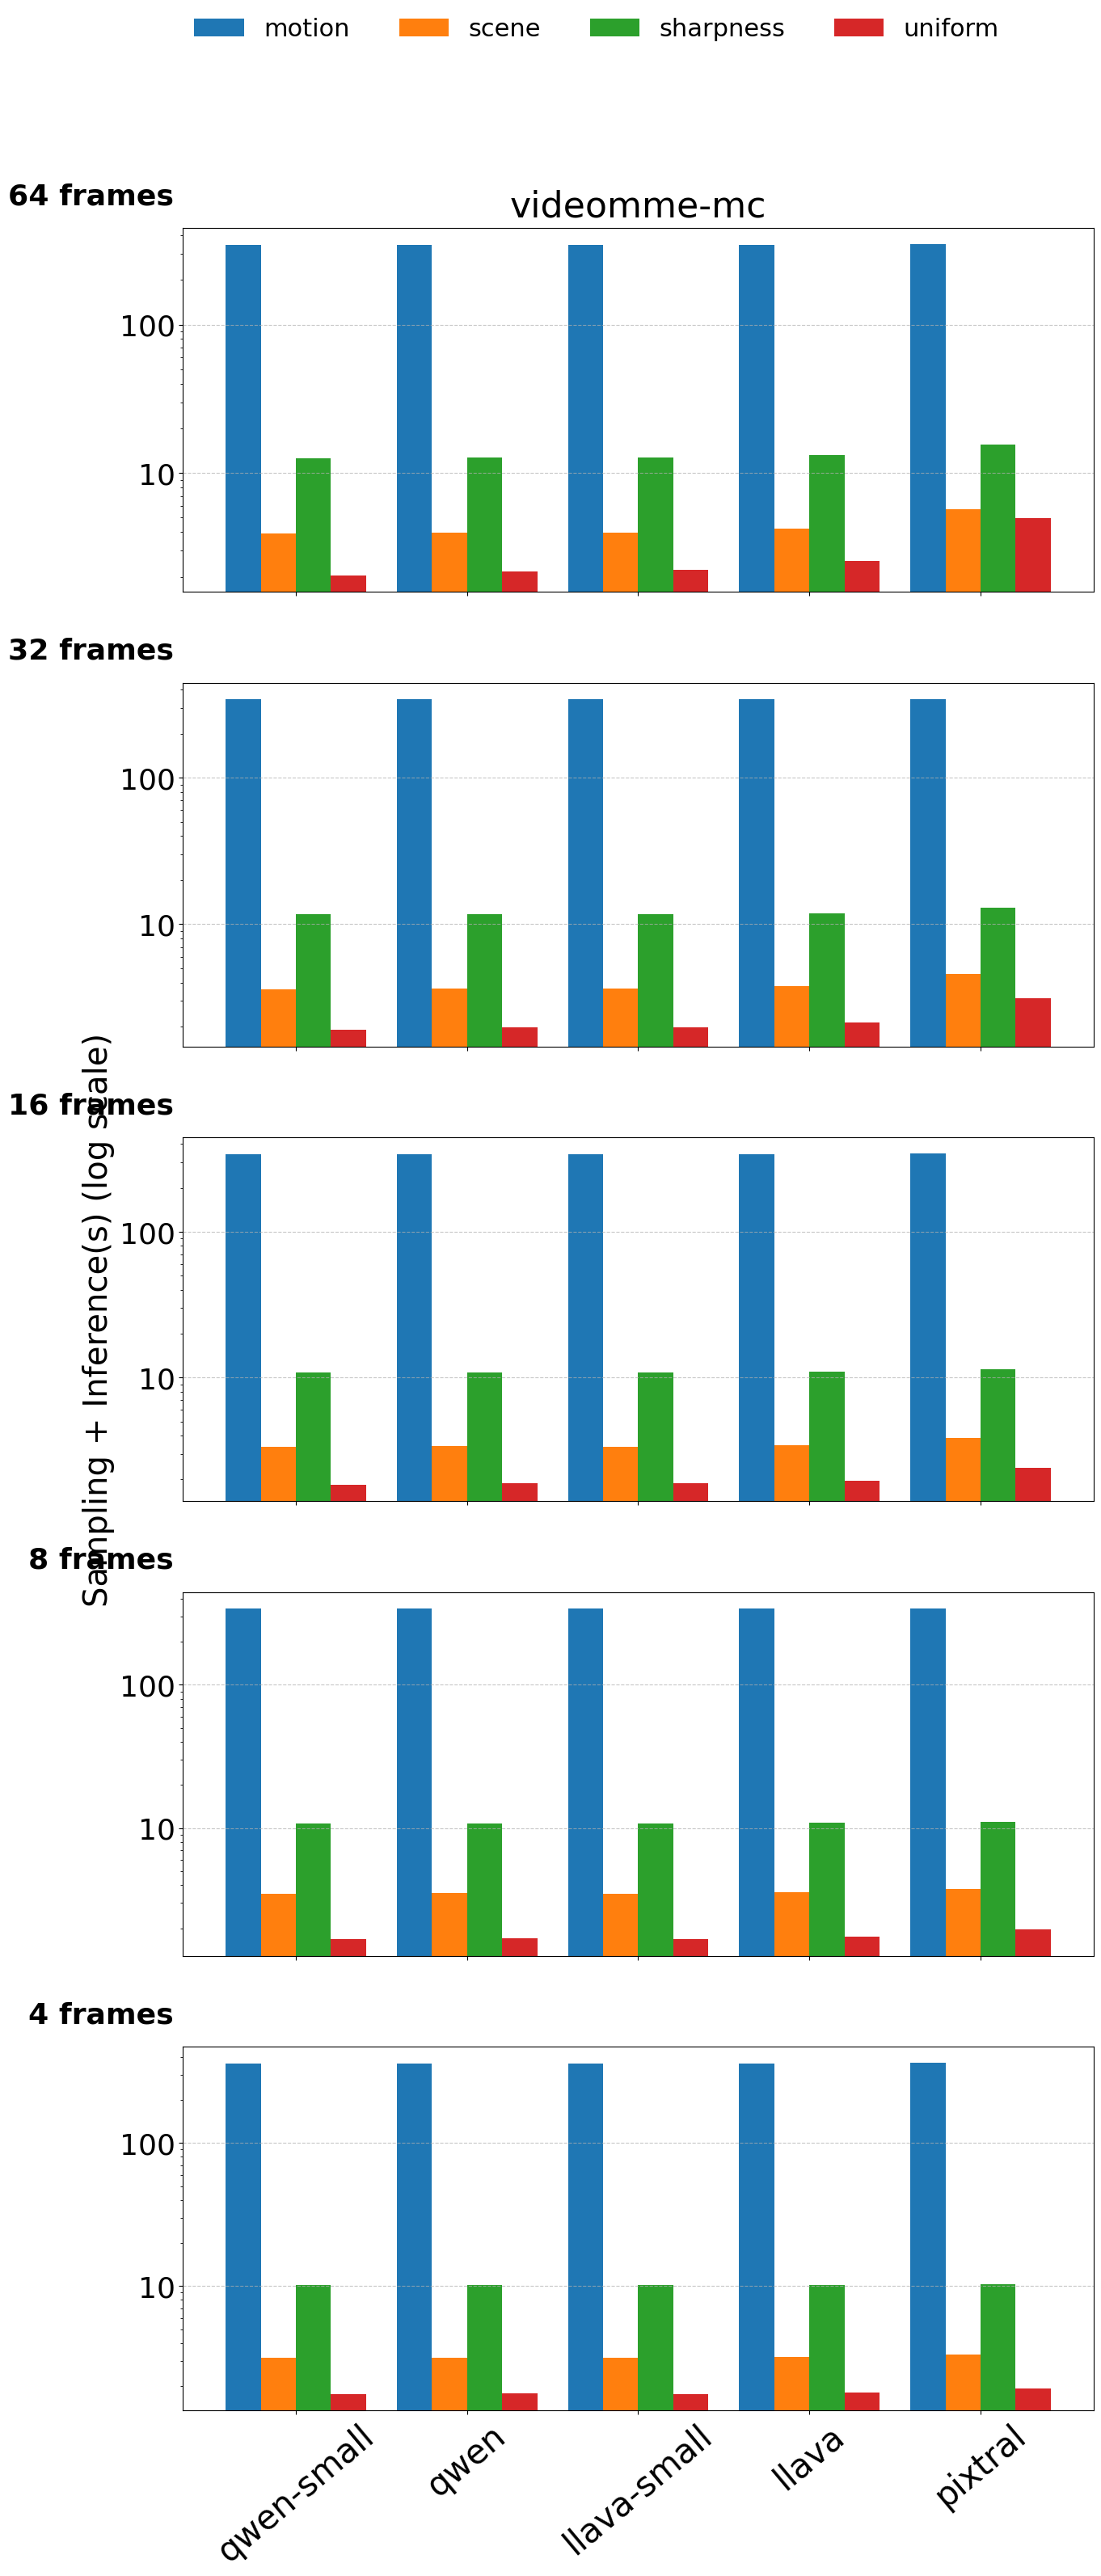

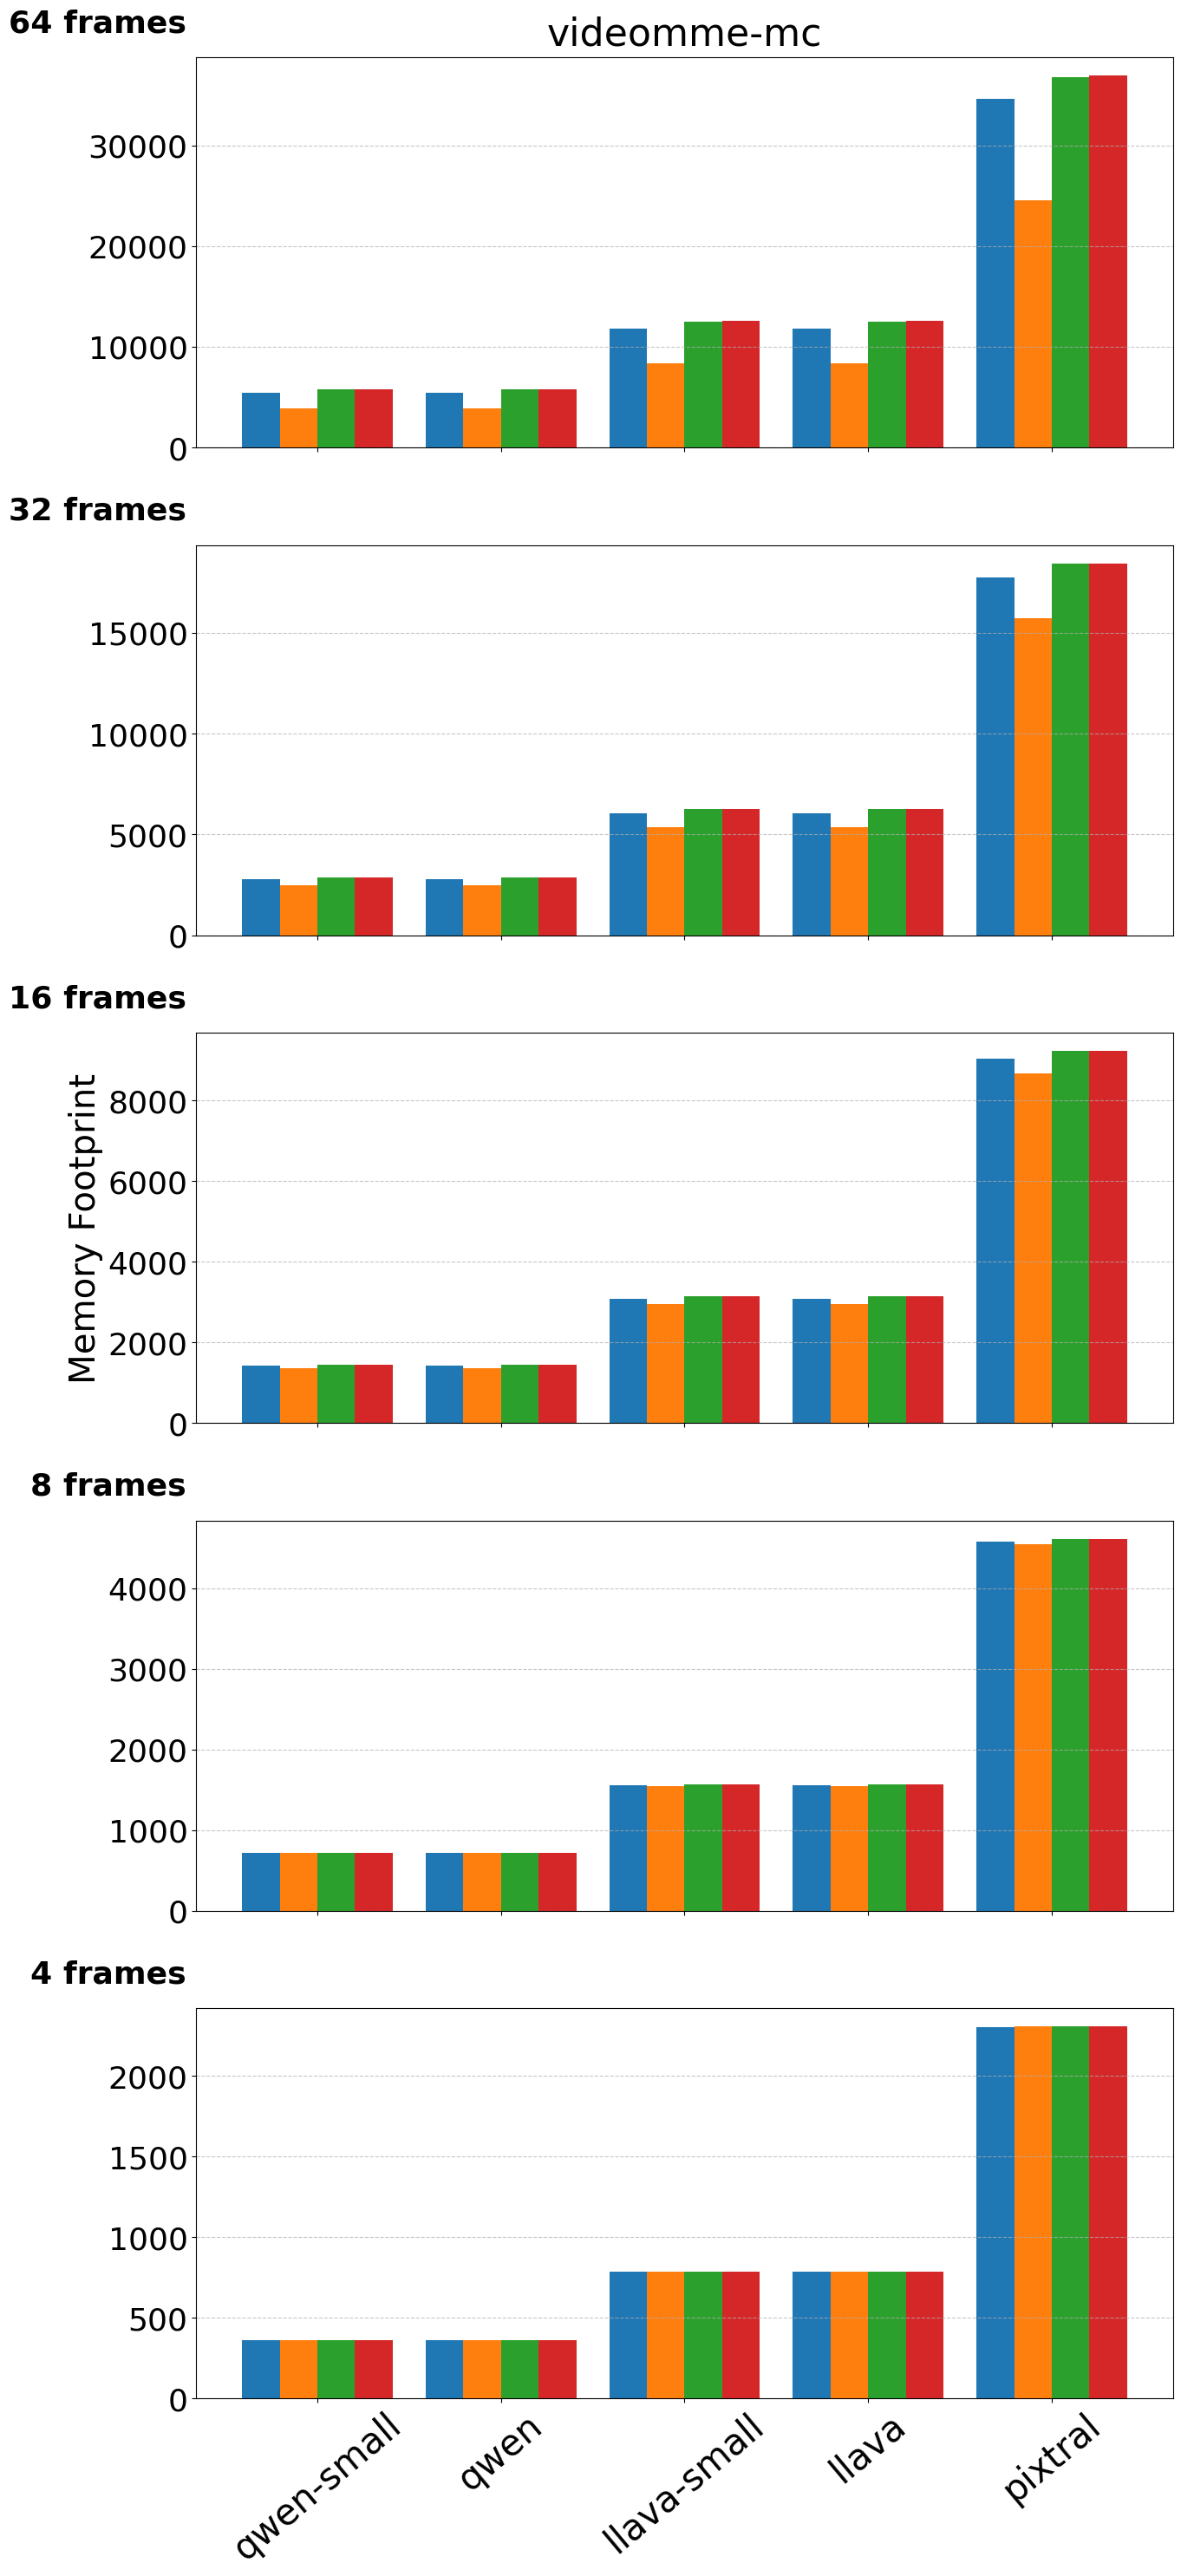

In [486]:
modes=[
    "model-technique|frame", # groups techniques by model and makes different plots for each frame
    # "model-frame|technique", # groups frames by model and makes different plots for each technique

    # "technique-frame|model",
    # "technique-model|frame",

    # "frame-model|technique",
    # "frame-technique|model",
    ]

for task in ["videomme-mc"]:
    for mode in modes:
        print(f"Plotting for task {task} in mode {mode}")

        avg_modality_tokens_removes = filter_nested_data(
            avg_modality_tokens,
            remove_tasks={},
            remove_models={}, 
            remove_frames=remove_frames,
            remove_techniques={}
        )
        scores_removes = filter_nested_data(
            scores,
            remove_tasks={},
            remove_models={}, 
            remove_frames=remove_frames,
            remove_techniques={}
        )
        ttfts_removes = filter_nested_data(
            ttfts,
            remove_tasks={},
            remove_models={}, 
            remove_frames=remove_frames,
            remove_techniques={}
        )
        
        _ = plot_grouped_video_bars(scores_removes, task, mode=mode, show_legend=True, color_map="categorical", add_plot_title=True)
        _ = plot_grouped_video_bars(ttfts_with_prep_time, task, mode=mode, show_legend=True, title="Sampling + Inference(s)",
                                    log_threshold=20, color_map="categorical", add_plot_title=True)
        ###################### extra
        # _ = plot_grouped_video_bars(ttfts_removes, task, mode=mode, show_legend=True, title="Latency (s)",
        #                             log_threshold=10, color_map="categorical", add_plot_title=True)
        # _ = plot_grouped_video_bars(prompt_preparation_times, task, mode=mode, show_legend=True, title="Sampling (s)",
        #                             log_threshold=10, color_map="categorical", add_plot_title=True)
        ###################### extra
        _ = plot_grouped_video_bars(avg_modality_tokens_removes, task, mode=mode, title="Memory Footprint", show_legend=False,
                                    color_map="categorical", add_plot_title=True)

Plotting for task mmbench-video-qna in mode model-frame|technique


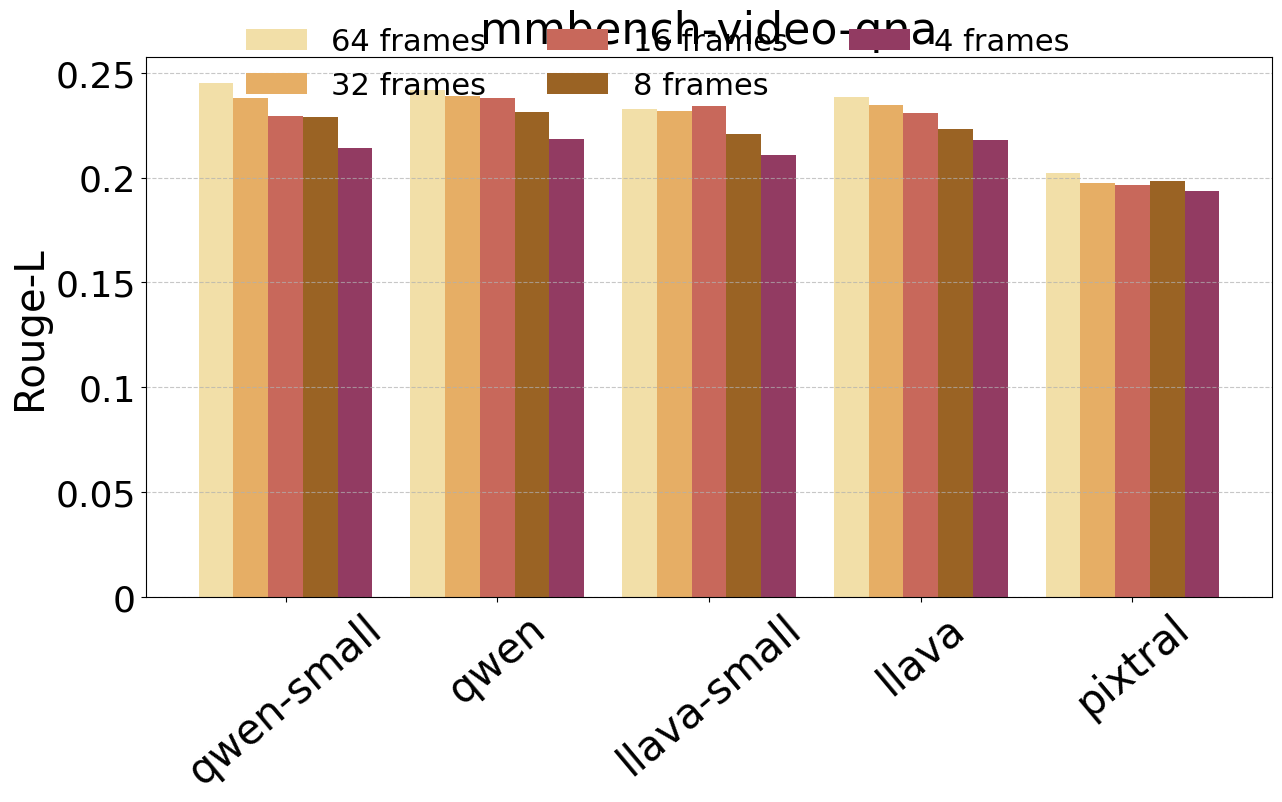

Average change from baseline: -4.513470866709449


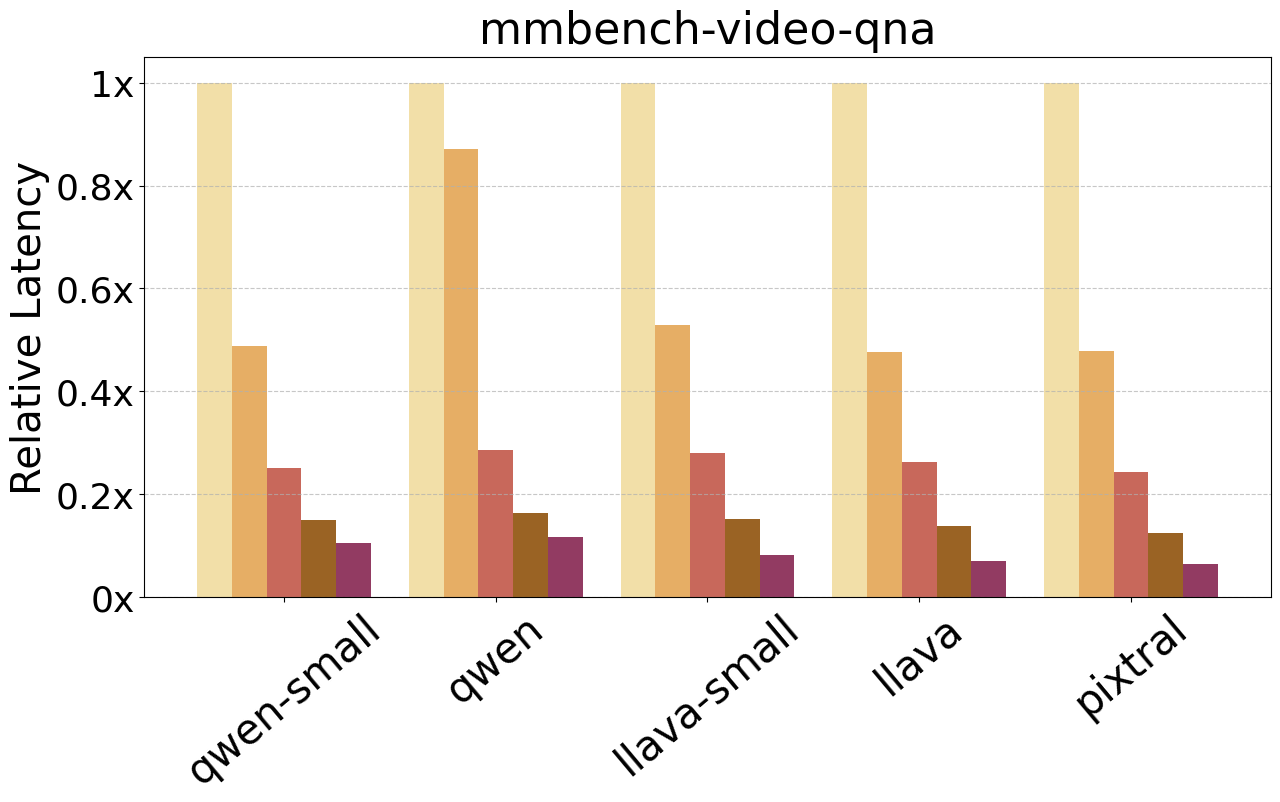

Average relative latency reduction: 0.26631687758774314


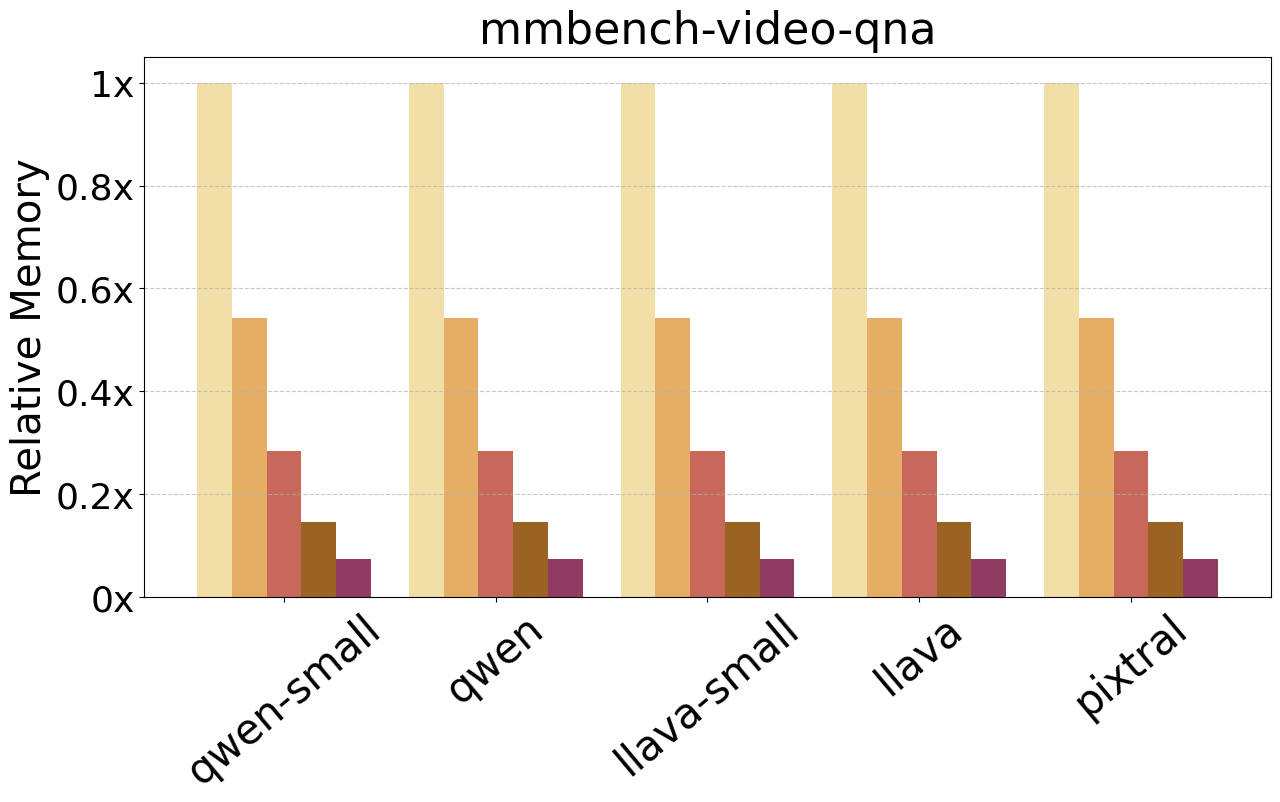

Average relative memory reduction: 0.26154733675039116


In [487]:
modes=[
    "model-frame|technique", # groups frames by model and makes different plots for each technique
    ]
tasks = [
    # 'videomme-mc',
    # 'tempcompass-captioning',
    'mmbench-video-qna',
]
remove_techniques={"uniform", "sharpness_based", "motion_based"}

for task in tasks:
    for mode in modes:
        print(f"Plotting for task {task} in mode {mode}")

        title = "Accuracy" if task in ["videomme-mc"] else "Rouge-L"

        ttfts_all_frames_only_task = filter_nested_data(
            ttfts,
            remove_tasks= experiment_ids.keys() - {task},
            remove_models={},
            remove_frames={}, 
            remove_techniques=remove_techniques
        )
        avg_modality_tokens_all_frames_only_task = filter_nested_data(
            avg_modality_tokens,
            remove_tasks= experiment_ids.keys() - {task},
            remove_models={},
            remove_frames={}, 
            remove_techniques=remove_techniques
        )
        scores_all_frames_only_task = filter_nested_data(
            scores,
            remove_tasks= experiment_ids.keys() - {task},
            remove_models={}, 
            remove_frames={},
            remove_techniques=remove_techniques
        )
        
        _ = plot_grouped_video_bars(scores_all_frames_only_task, task, title=title, mode=mode, show_legend=True, add_plot_title=False)
        print("Average change from baseline:",
            calculate_average_change_from_base(data_structure=scores_all_frames_only_task, comparison_key="frame64")[0]
        )
        
        ttft_reductions = normalize_nested_data_to_base_frame(ttfts_all_frames_only_task, direction='small_to_big')
        _ = plot_grouped_video_bars(ttft_reductions, task, mode=mode, title="Relative Latency", show_legend=False, add_suffix=True,
                                    add_plot_title=False)
        print("Average relative latency reduction:",
            calculate_average_relative_score(data_structure=ttft_reductions, comparison_key="frame64")
        )
        
        tokens_reductions = normalize_nested_data_to_base_frame(avg_modality_tokens_all_frames_only_task, direction='small_to_big')
        _ = plot_grouped_video_bars(tokens_reductions, task, mode=mode, title="Relative Memory", show_legend=False, add_suffix=True,
                                    add_plot_title=False)
        tokens_reductions_only_task = filter_nested_data(
            tokens_reductions,
            remove_tasks = experiment_ids.keys() - {task},
            remove_models={}, 
            remove_frames={}, 
            remove_techniques={}
        )
        print("Average relative memory reduction:",
            calculate_average_relative_score(data_structure=tokens_reductions_only_task, comparison_key="frame64")
        )

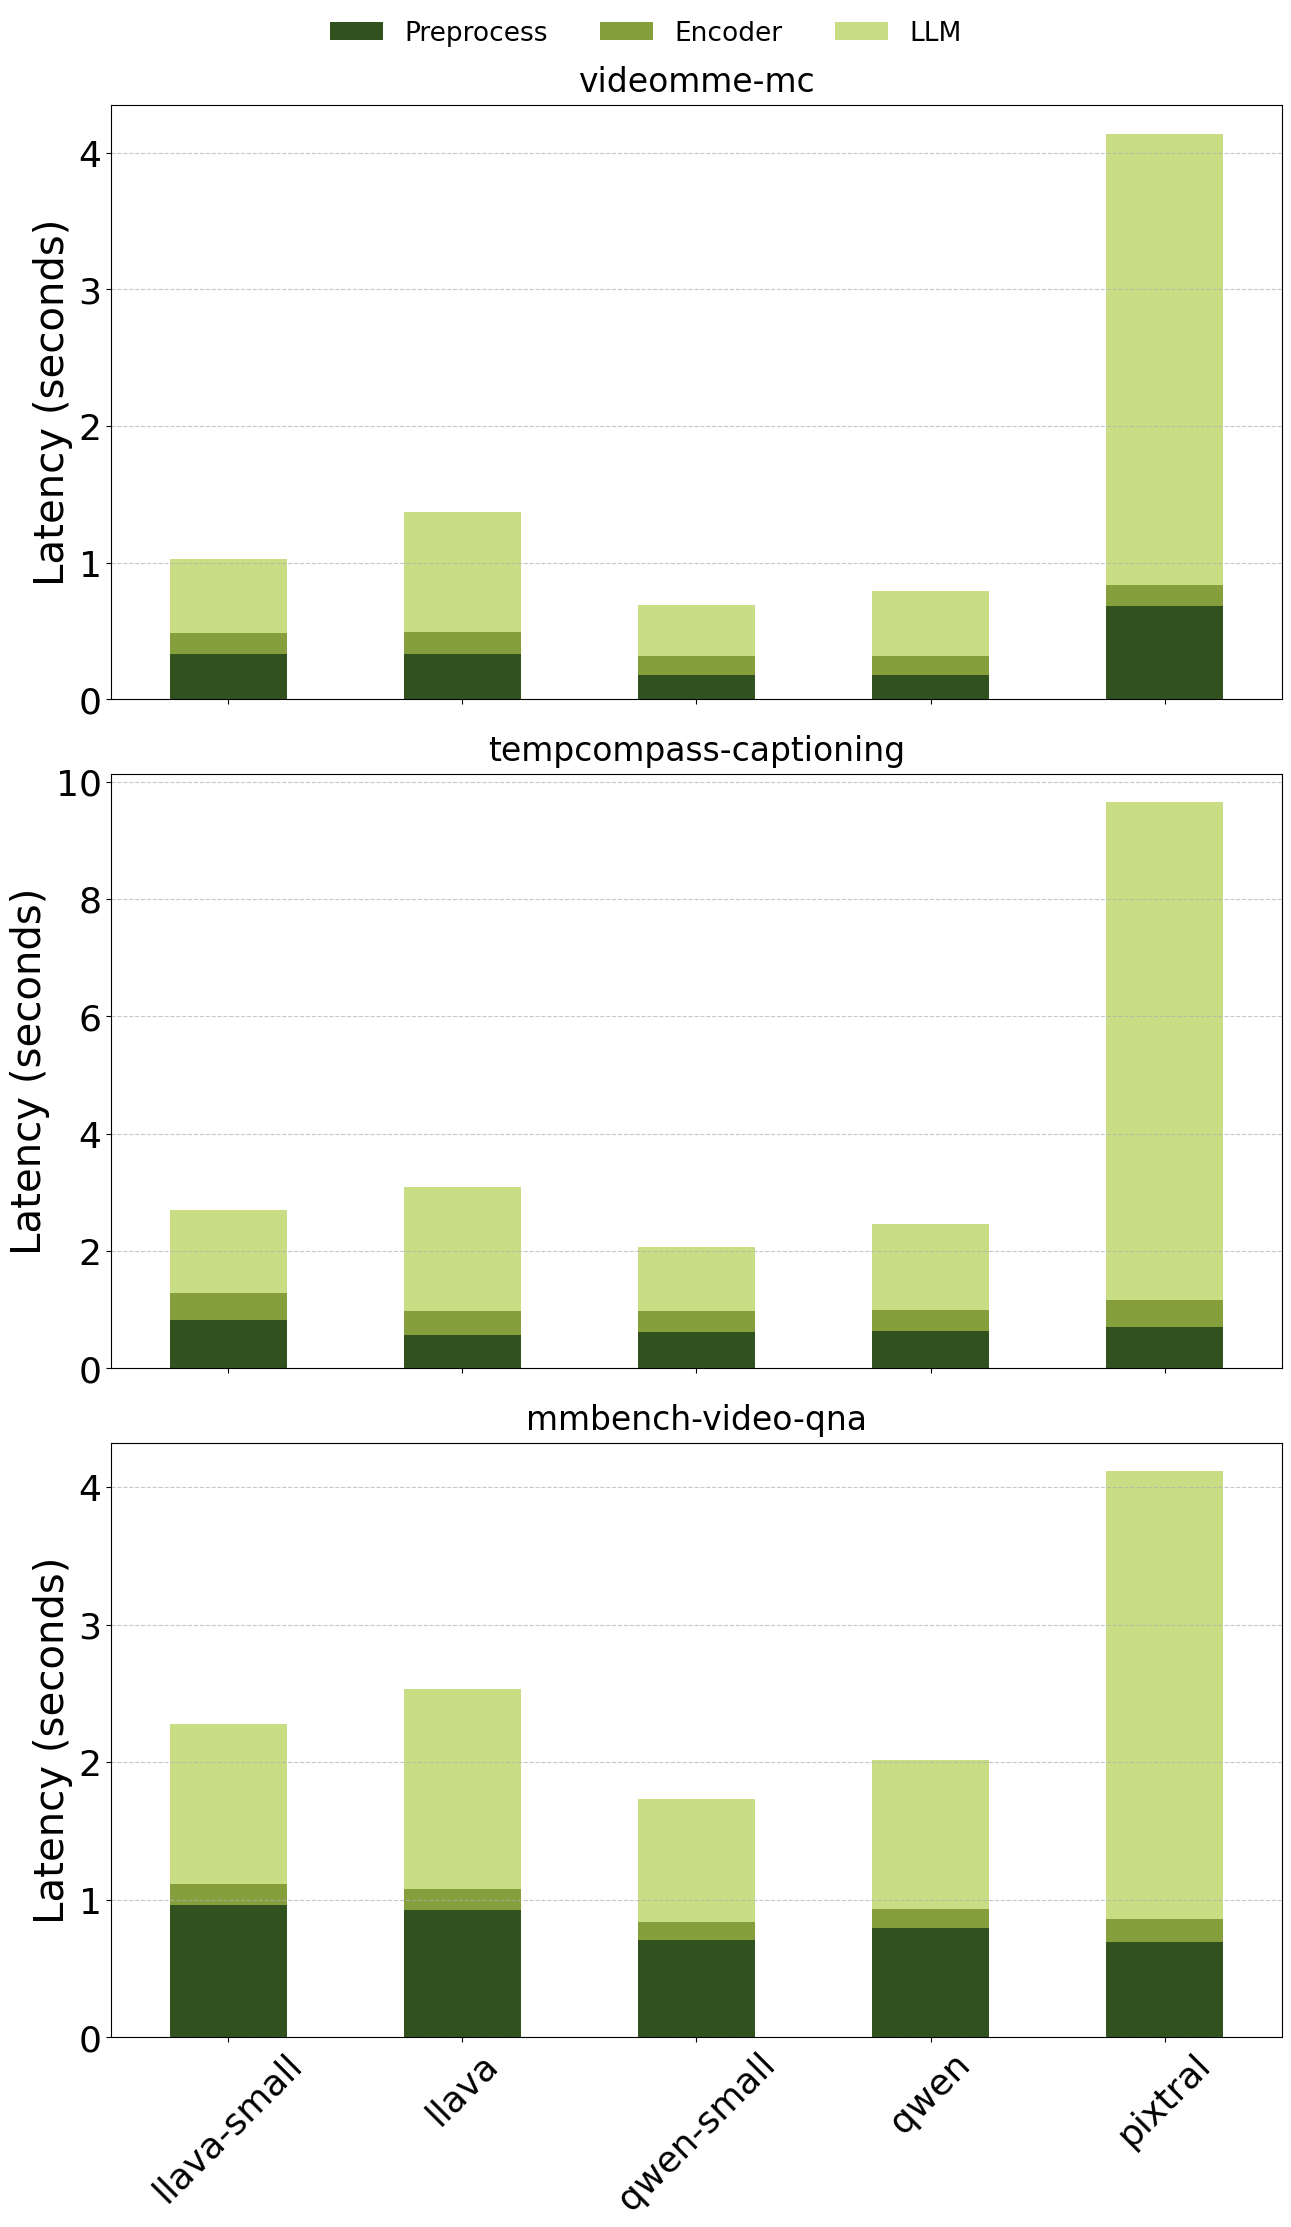

In [488]:
# plot_latency_breakdown_videos(preprocess_times, encoder_times, ttfts, dataset_name='videomme-mc')
fig = plot_latency_breakdown_videos(preprocess_times, encoder_times, ttfts,
                             dataset_name=['videomme-mc', 'tempcompass-captioning', 'mmbench-video-qna'])
# save_figure_as_pdf(fig, "video_latency_breakdown")